<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/3D_Spin_Representation_Mesh_Using_Trimesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

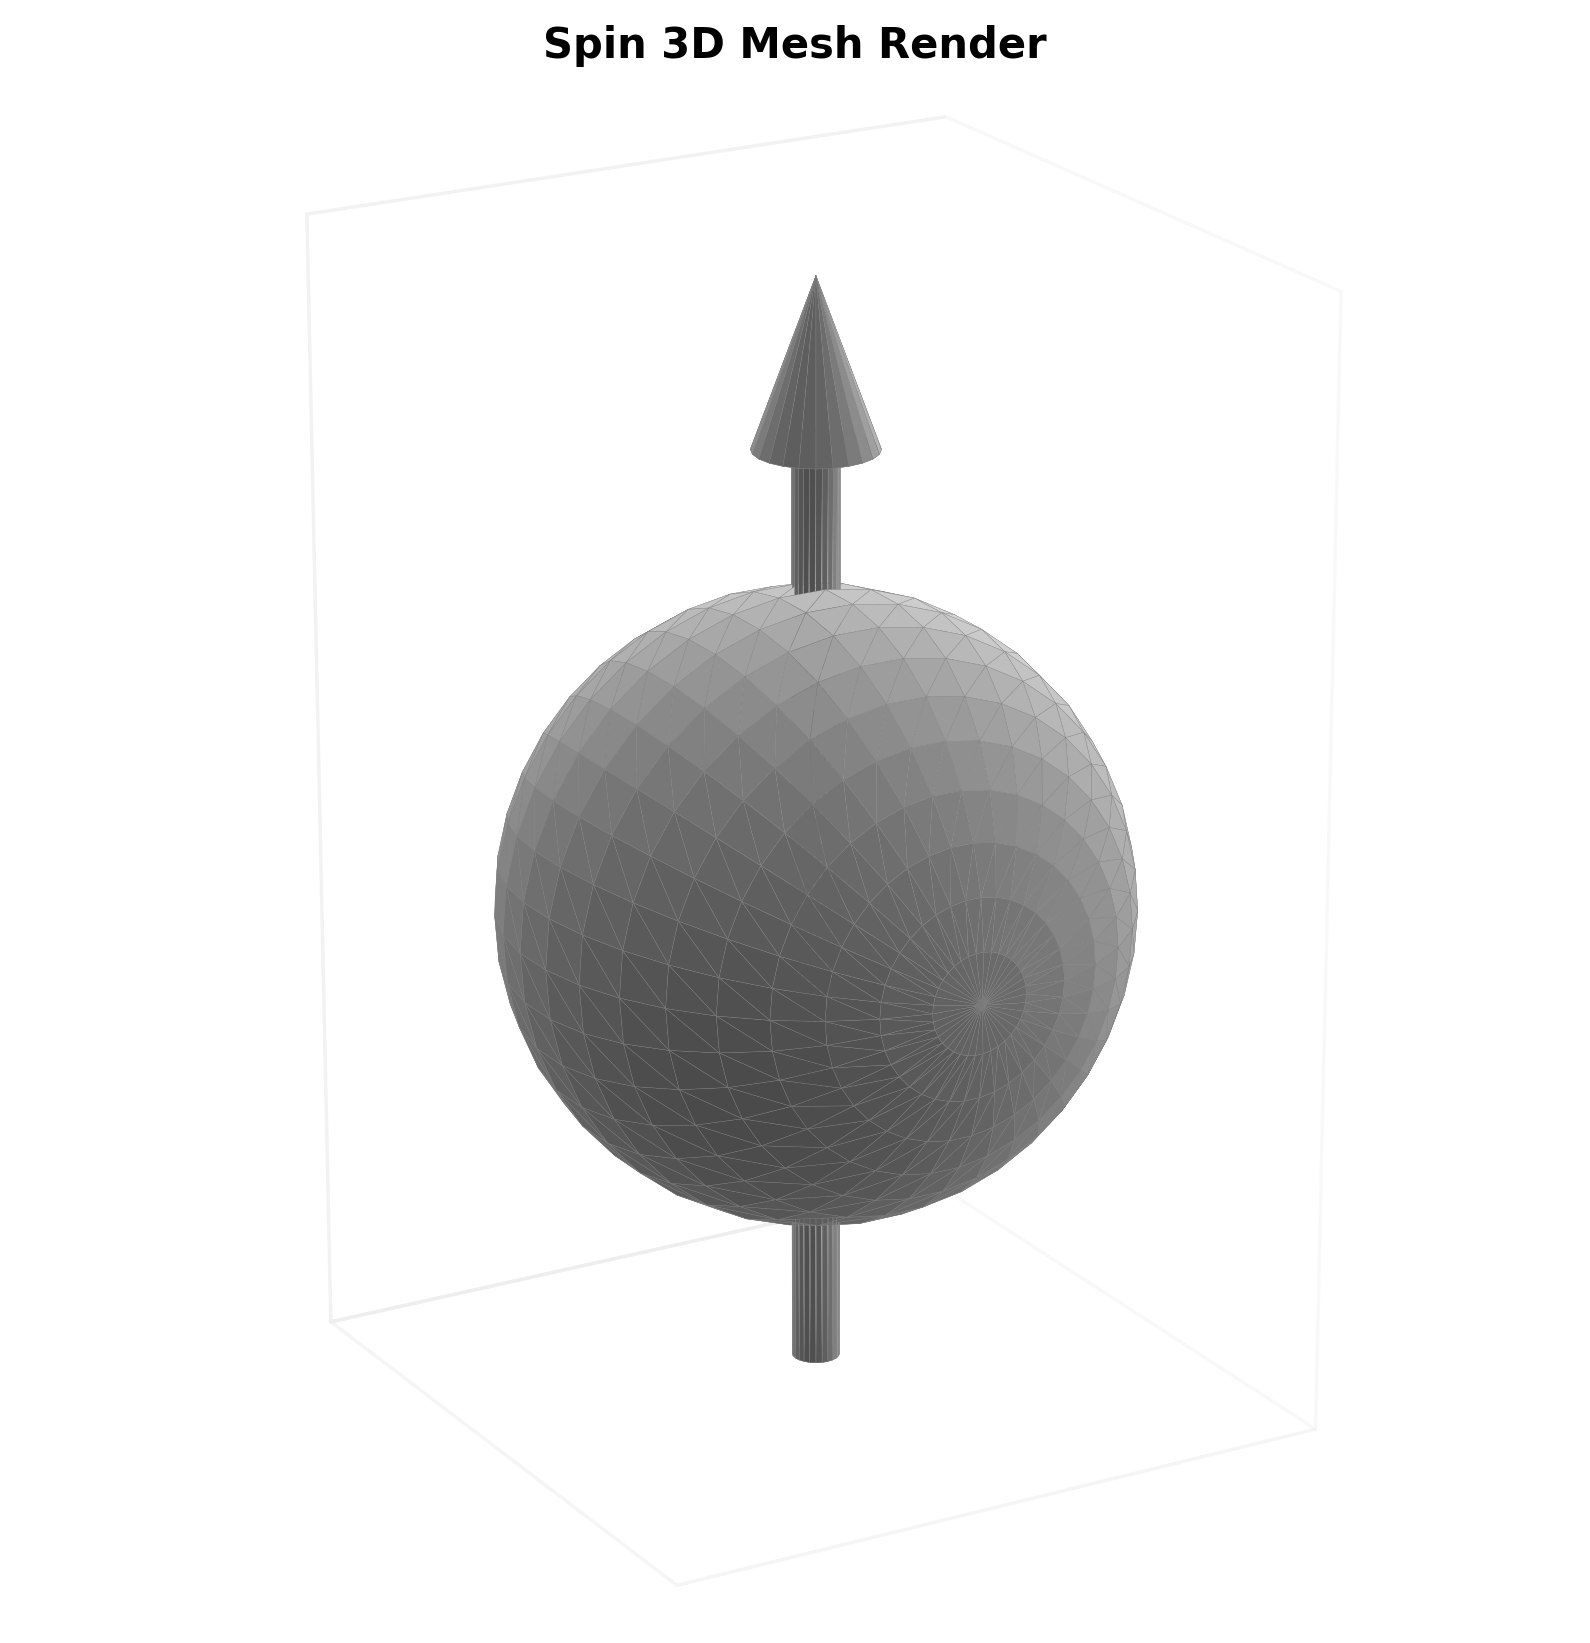

In [ ]:
# Install the required dependency within the notebook environment
%pip install trimesh

"""
Retrieves and renders a three dimensional Object File Format mesh from a remote repository,
handling complex scene concatenations automatically.
"""
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import trimesh

# --- Control Knobs ---
REMOTE_URL = "https://raw.githubusercontent.com/OJB-Quantum/QC-Hardware-How-To/main/3D_Models/1%20Spin%20v1.obj"
LOCAL_FILENAME = "1_Spin_v1.obj"
ROTATION_DEGREES = 90.0
VIEW_ELEVATION = 20
VIEW_AZIMUTH = 60
MESH_COLOR = 'whitesmoke'
EDGE_COLOR = 'gray'
LINE_WIDTH = 0.1
FIGURE_DPI = 250

# Configure Matplotlib parameters for Nature-style formatting
mpl.rcParams['figure.dpi'] = FIGURE_DPI
mpl.rcParams['font.sans-serif'] = ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif']
mpl.rcParams['font.weight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'semibold'

def process_and_render_mesh() -> None:
    """
    Downloads the designated object file, forces scene concatenation,
    and renders the structural vertices directly to the notebook display.
    """
    try:
        urllib.request.urlretrieve(REMOTE_URL, LOCAL_FILENAME)

        # The force='mesh' parameter coerces any complex Scene container into a single Trimesh object
        mesh = trimesh.load(LOCAL_FILENAME, force='mesh')

    except Exception as network_error:
        print(f"The system failed to load the model from the provided network path. Error details follow.\n{network_error}")
        return

    # A rotation matrix provides mathematical manipulation of the geometric coordinates
    theta = np.radians(ROTATION_DEGREES)
    rotation_matrix = np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ])

    rotated_vertices = mesh.vertices @ rotation_matrix.T

    figure = plt.figure(figsize=(10, 8))
    axis = figure.add_subplot(111, projection='3d')

    axis.plot_trisurf(
        rotated_vertices[:, 0], rotated_vertices[:, 1], rotated_vertices[:, 2],
        triangles=mesh.faces,
        color=MESH_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=LINE_WIDTH
    )

    axis.set_title("Spin 3D Mesh Render")
    axis.view_init(elev=VIEW_ELEVATION, azim=VIEW_AZIMUTH)
    axis.set_aspect('equal')

    # The grid and background planes undergo formatting to maintain a sophisticated appearance
    axis.grid(False)
    axis.xaxis.pane.fill = False
    axis.yaxis.pane.fill = False
    axis.zaxis.pane.fill = False
    axis.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    axis.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    axis.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_zticks([])

    plt.show()

if __name__ == "__main__":
    process_and_render_mesh()